# **HW-5**
- **Name: Janga Tushita Sharva**  
- **Roll Number: CS21BTECH11022**

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np
import warnings
import random
from sklearn.manifold import TSNE
import time
warnings.filterwarnings("ignore")

## **Q1: ALEXNET AND RESNET**

In [31]:
alexnet = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=False)
resnet = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=False)

Using cache found in C:\Users\tushi/.cache\torch\hub\pytorch_vision_v0.10.0
Using cache found in C:\Users\tushi/.cache\torch\hub\pytorch_vision_v0.10.0


In [32]:
# print the model summary for both models
print("AlexNet Summary")
print(summary(alexnet, (3, 224, 224)))

AlexNet Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 55, 55]          23,296
              ReLU-2           [-1, 64, 55, 55]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
AdaptiveAvgPool2d-14   

In [33]:
print("ResNet Summary")
print(summary(resnet, (3, 224, 224)))

ResNet Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14    

In [34]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = torchvision.datasets.CIFAR10(root='./data_', train=True, download=True, transform=preprocess)

KeyboardInterrupt: 

In [ ]:
print(type(dataset))
print(type(dataset[0]))
# print(dataset[0]) # this will print the image, a tensor of (3, 224, 224) and the label
print(type(dataset[0][0]))
print(dataset[0][0].shape)
print(len(dataset))

<class 'torchvision.datasets.cifar.CIFAR10'>
<class 'tuple'>
<class 'torch.Tensor'>
torch.Size([3, 224, 224])
50000


In [ ]:
# Taking 200 images per class, for all 10 unique classes in the dataset as new dataset
new_dataset = []
count = [0]*10
for i in range(len(dataset)):
    if count[dataset[i][1]] < 200:
        new_dataset.append(dataset[i])
        count[dataset[i][1]] += 1
    if sum(count) == 2000:
        break

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# Extract labels from the new dataset
labels = [sample[1] for sample in new_dataset]  # Assuming dataset[i] = (image, label)

# Split indices for stratified sampling
train_idx, temp_idx = train_test_split(
    range(len(new_dataset)),
    test_size=0.3,  # Combined size for validation and test
    stratify=labels
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.33,  # 33% of temp (10% of total)
    stratify=[labels[i] for i in temp_idx]
)

# Create subsets
train_subset = Subset(new_dataset, train_idx)
val_subset = Subset(new_dataset, val_idx)
test_subset = Subset(new_dataset, test_idx)

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

In [ ]:
# print(len(train_loader))
# print(len(val_loader))
# print(len(test_loader))

In [ ]:
def train(model, train_loader, val_loader, test_loader, epochs, optimizer, should_stop=10):
    best_val_loss = float('inf')
    best_model = model
    stop = 0

    train_losses, val_losses = [], []
    train_accs, val_accs= [], []

    for epoch in range(epochs):
        # Training starts here
        model.train()
        train_loss = 0.0
        train_acc = 0.0
        train_samples = 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            prediction = torch.argmax(outputs, 1)
            train_acc += (prediction == labels).sum().item()
            train_samples += len(labels)

        train_losses.append(train_loss / train_samples)
        train_accs.append(train_acc / train_samples)

        # Validation starts here
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        val_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = F.cross_entropy(outputs, labels)

                val_loss += loss.item() * images.size(0)
                prediction = torch.argmax(outputs, 1)
                val_acc += (prediction == labels).sum().item()
                val_samples += len(labels)

        val_losses.append(val_loss / val_samples)
        val_accs.append(val_acc / val_samples)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

        # updating the best loss and best model (and early stopping)
        stop = 0 + (stop + 1) * (val_loss < best_val_loss)
        if stop > should_stop:
            break

        if val_loss < best_val_loss:
            best_model = model
            best_val_loss = val_loss

    # Testing starts here
    model.eval()
    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    test_samples = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            test_samples += len(labels)

            test_loss += loss.item() * images.size(0)
            prediction = torch.argmax(outputs, 1)
            test_acc += (prediction == labels).sum().item()
            test_loss = test_loss / test_samples
            test_acc = test_acc / test_samples

    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    return best_model, train_losses, val_losses, test_loss, train_accs, val_accs, test_acc

### **AlexNet**

In [37]:
# optimizer = torch.optim.Adam(alexnet.parameters(), lr=0.001) # without weight decay results: Test Loss: 462.3690, Test Acc: 18.0000
optimizer = torch.optim.Adam(alexnet.parameters(), lr=0.0003, weight_decay=0.0005)
start_time_alex = time.perf_counter()
alexnet, train_losses_alex, val_losses_alex, test_loss_alex, train_accs_alex, val_accs_alex, test_acc_alex = train(alexnet, train_loader, val_loader, test_loader, 30, optimizer)
end_time_alex = time.perf_counter()

time_alex = end_time_alex - start_time_alex

Epoch 1/30, Train Loss: 3.2804, Train Acc: 0.1071, Val Loss: 2.4161, Val Acc: 0.0995
Epoch 2/30, Train Loss: 2.3038, Train Acc: 0.1236, Val Loss: 2.1390, Val Acc: 0.2164
Epoch 3/30, Train Loss: 2.1372, Train Acc: 0.2107, Val Loss: 1.9354, Val Acc: 0.2736
Epoch 4/30, Train Loss: 1.9894, Train Acc: 0.2507, Val Loss: 1.9409, Val Acc: 0.2836
Epoch 5/30, Train Loss: 1.9183, Train Acc: 0.2786, Val Loss: 1.7951, Val Acc: 0.3184
Epoch 6/30, Train Loss: 1.8410, Train Acc: 0.3064, Val Loss: 1.7066, Val Acc: 0.3284
Epoch 7/30, Train Loss: 1.7198, Train Acc: 0.3550, Val Loss: 1.6669, Val Acc: 0.3731
Epoch 8/30, Train Loss: 1.6936, Train Acc: 0.3529, Val Loss: 1.6783, Val Acc: 0.3781
Epoch 9/30, Train Loss: 1.6232, Train Acc: 0.4029, Val Loss: 1.6934, Val Acc: 0.3881
Epoch 10/30, Train Loss: 1.5874, Train Acc: 0.4021, Val Loss: 1.5886, Val Acc: 0.4005
Epoch 11/30, Train Loss: 1.4624, Train Acc: 0.4536, Val Loss: 1.5585, Val Acc: 0.4303
Epoch 12/30, Train Loss: 1.3708, Train Acc: 0.4936, Val Loss: 1

### **ResNet**

In [38]:
optimizer = torch.optim.Adam(resnet.parameters(), lr=0.0003, weight_decay=0.0005)
start_time_res = time.perf_counter()
resnet, train_losses_res, val_losses_res, test_loss_res, train_accs_res, val_accs_res, test_acc_res = train(resnet, train_loader, val_loader, test_loader, 30, optimizer)
end_time_res = time.perf_counter()
time_res = end_time_res - start_time_res

Epoch 1/30, Train Loss: 3.0085, Train Acc: 0.2500, Val Loss: 1.7851, Val Acc: 0.3308
Epoch 2/30, Train Loss: 1.7202, Train Acc: 0.4000, Val Loss: 1.7691, Val Acc: 0.3433
Epoch 3/30, Train Loss: 1.5752, Train Acc: 0.4193, Val Loss: 1.6219, Val Acc: 0.3856
Epoch 4/30, Train Loss: 1.4365, Train Acc: 0.4771, Val Loss: 1.9785, Val Acc: 0.3234
Epoch 5/30, Train Loss: 1.2386, Train Acc: 0.5507, Val Loss: 1.6842, Val Acc: 0.3930
Epoch 6/30, Train Loss: 1.1458, Train Acc: 0.5850, Val Loss: 1.5372, Val Acc: 0.4502
Epoch 7/30, Train Loss: 0.9888, Train Acc: 0.6593, Val Loss: 2.5487, Val Acc: 0.3383
Epoch 8/30, Train Loss: 0.7608, Train Acc: 0.7486, Val Loss: 2.6108, Val Acc: 0.3109
Epoch 9/30, Train Loss: 0.5759, Train Acc: 0.8136, Val Loss: 2.2464, Val Acc: 0.3731
Epoch 10/30, Train Loss: 0.3947, Train Acc: 0.8814, Val Loss: 2.1524, Val Acc: 0.3682
Epoch 11/30, Train Loss: 0.2739, Train Acc: 0.9229, Val Loss: 2.0519, Val Acc: 0.4378
Epoch 12/30, Train Loss: 0.1530, Train Acc: 0.9643, Val Loss: 1

##### **1.A: Plot errors as a function of epochs**

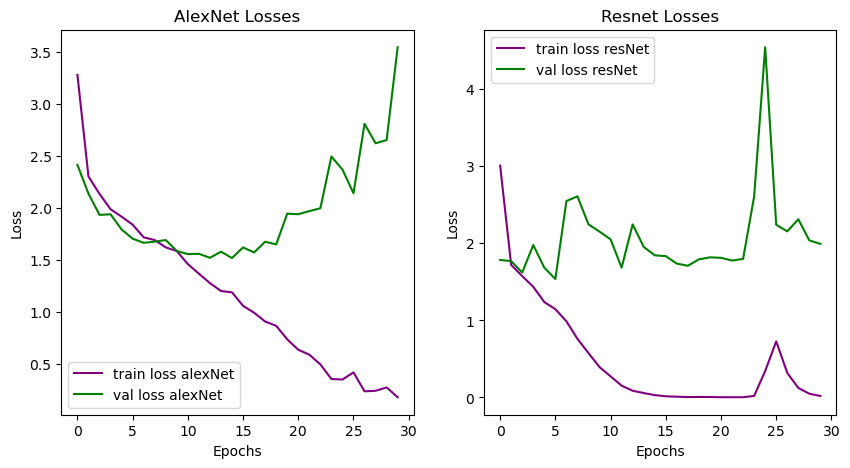

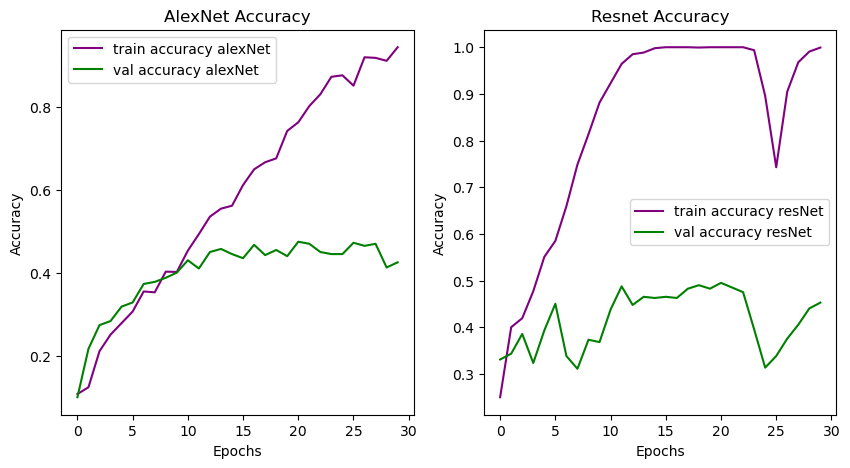

In [39]:
# plotting train and val losses of both models in one plot with two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_alex, label='train loss alexNet', color='purple')
plt.plot(val_losses_alex, label='val loss alexNet', color='green')
plt.title('AlexNet Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses_res, label='train loss resNet', color='purple')
plt.plot(val_losses_res, label='val loss resNet', color='green')
plt.title('Resnet Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# plotting train and val accuracies of both models in one plot with two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accs_alex, label='train accuracy alexNet', color='purple')
plt.plot(val_accs_alex, label='val accuracy alexNet', color='green')
plt.title('AlexNet Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs_res, label='train accuracy resNet', color='purple')
plt.plot(val_accs_res, label='val accuracy resNet', color='green')
plt.title('Resnet Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

##### **1.B: Visualize the activation maps of trained model**

In [40]:
# Initialize lists to store activation maps from different stages
conv_layer_maps_alex = []
pooled_maps_alex = []

# Iterate through the test dataset without calculating gradients
with torch.no_grad():
    for batch_idx, (batch_images, _) in enumerate(test_loader):
        # Select the first image from the current batch for visualization
        single_image = batch_images[:1]  # Shape: (1, C, H, W)

        # Extract activation map from the convolutional layers
        conv_map_alex = alexnet.features(single_image)
        conv_layer_maps_alex.append(conv_map_alex)

        # Extract activation map after average pooling
        pooled_map_alex = alexnet.avgpool(conv_map_alex)
        pooled_maps_alex.append(pooled_map_alex)

# Now, conv_layer_maps contains feature maps from the convolutional layers,
# and pooled_maps contains the activation maps after average pooling.

Activation Map 1: tensor([[0.0000, 0.0000, 0.2969, 0.2969, 0.3026, 0.2505],
        [0.0000, 0.0000, 0.2969, 0.6661, 0.6921, 0.4749],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
Activation Map 2: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0875],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0875],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
Activation Map 3: tensor([[0.0000, 0.0000, 0.0044, 0.0000, 0.0000, 0.0000],
        [0.1129, 0.1129, 0.0644, 0.2832, 0.4762, 0.1778],
        [0.1129, 0.1129, 0.0000, 0.2832, 0.4762, 0.0360],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000,

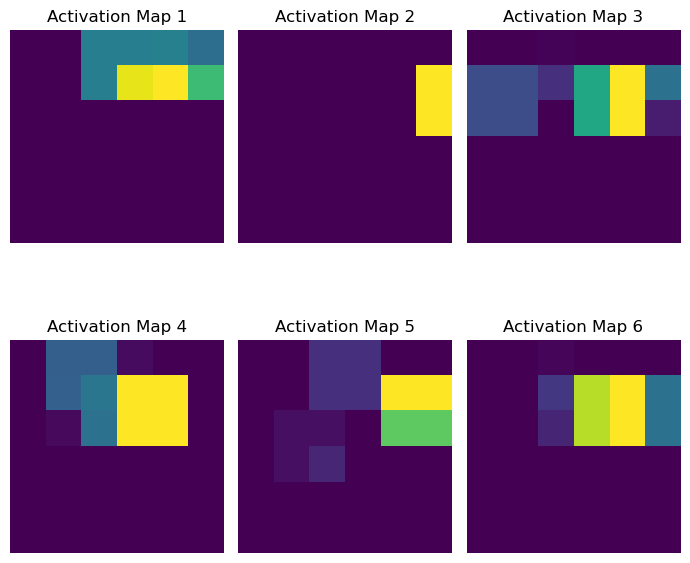

Activation Map 1: tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
Activation Map 2: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0487, 0.0000, 0.0000, 0.0000, 0.0000, 0.2344],
        [0.2480, 0.0000, 0.0000, 0.0000, 0.0000, 0.3567],
        [0.2480, 0.0000, 0.0000, 0.0000, 0.0000, 0.3567],
        [0.1990, 0.0000, 0.2155, 0.2155, 0.0809, 0.0955],
        [0.1160, 0.0000, 0.1325, 0.1356, 0.0809, 0.0955]])
Activation Map 3: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0832, 0.0832, 0.3500, 0.3500],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3500, 0.3500],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
Activation Map 4: tensor([[0., 0., 0., 0., 

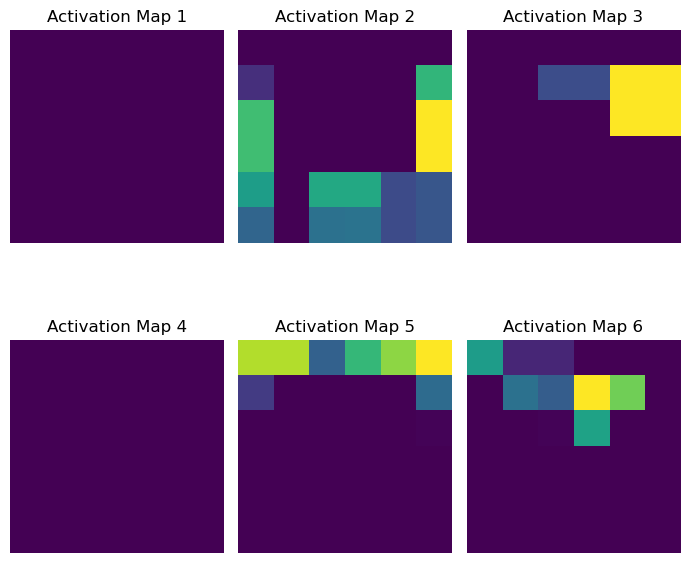

In [41]:
plt.figure(figsize=(7, 7))
for i in range(6):
    idx = random.randint(0, 256)
    plt.subplot(2, 3, i + 1)
    plt.imshow(conv_layer_maps_alex[0][0][idx])
    plt.title(f"Activation Map {i + 1}")
    plt.axis('off')
    print(f"Activation Map {i + 1}: {conv_layer_maps_alex[0][0][idx]}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
for i in range(6):
    idx = random.randint(0, 256)
    plt.subplot(2, 3, i + 1)
    plt.imshow(pooled_maps_alex[0][0][idx])
    plt.title(f"Activation Map {i + 1}")
    plt.axis('off')
    print(f"Activation Map {i + 1}: {pooled_maps_alex[0][0][idx]}")
plt.tight_layout()
plt.show()

In [42]:
# Activation map lists for each stage of the network
conv_activations, stage1_activations, stage2_activations, stage3_activations = [], [], [], []

with torch.no_grad():
    for idx, (images, _) in enumerate(test_loader):
        image = images[:1]
        conv_activation = resnet.conv1(image)
        conv_activations.append(conv_activation)
        activation_after_conv = resnet.bn1(conv_activation)
        activation_after_conv = resnet.relu(activation_after_conv)
        activation_after_conv = resnet.maxpool(activation_after_conv)
        stage1_activation = resnet.layer1(activation_after_conv)
        stage1_activation = resnet.layer2(stage1_activation)
        stage1_activations.append(stage1_activation)
        stage2_activation = resnet.layer3(stage1_activation)
        stage2_activation = resnet.layer4(stage2_activation)
        stage2_activations.append(stage2_activation)

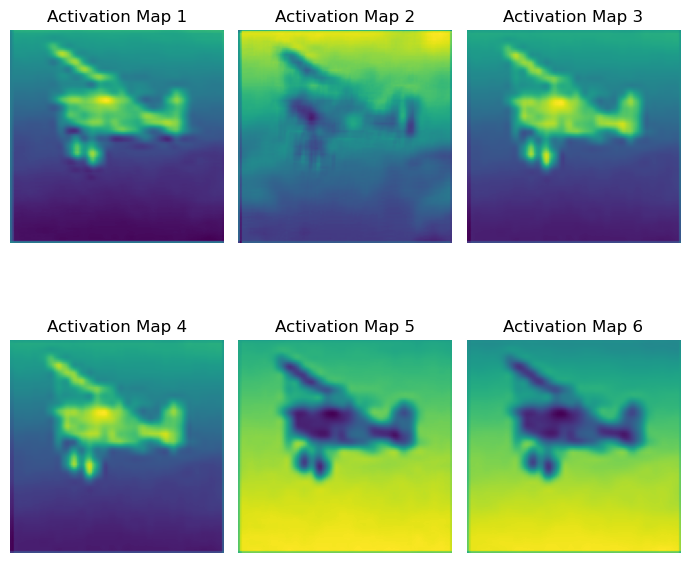

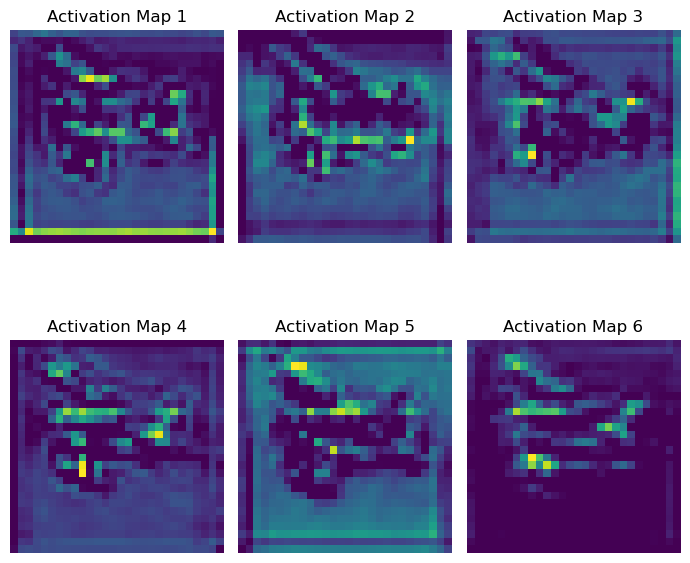

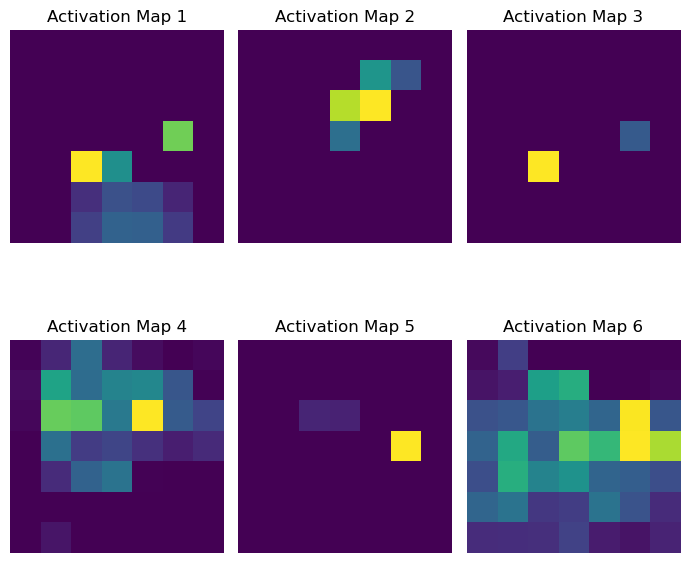

In [43]:
plt.figure(figsize=(7, 7))
for i in range(6):
    idx = random.randint(0, 63)
    plt.subplot(2, 3, i + 1)
    plt.imshow(conv_activations[0][0][idx])
    plt.title(f"Activation Map {i + 1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
for i in range(6):
    idx = random.randint(0, 63)
    plt.subplot(2, 3, i + 1)
    plt.imshow(stage1_activations[0][0][idx])
    plt.title(f"Activation Map {i + 1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
for i in range(6):
    idx = random.randint(0, 63)
    plt.subplot(2, 3, i + 1)
    plt.imshow(stage2_activations[0][0][idx])
    plt.title(f"Activation Map {i + 1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

##### **1.C: Report accuracy of your classifier**

In [44]:
print(f"Test accuracy of AlexNet: {test_acc_alex}\nTest accuracy of ResNet: {test_acc_res}")

Test accuracy of AlexNet: 0.025702026492766313
Test accuracy of ResNet: 0.010524369800792837


##### **1.D: Use tSNE to visualize the bottleneck feature at the end of first epoch and the last epoch**

<class 'torch.Tensor'>


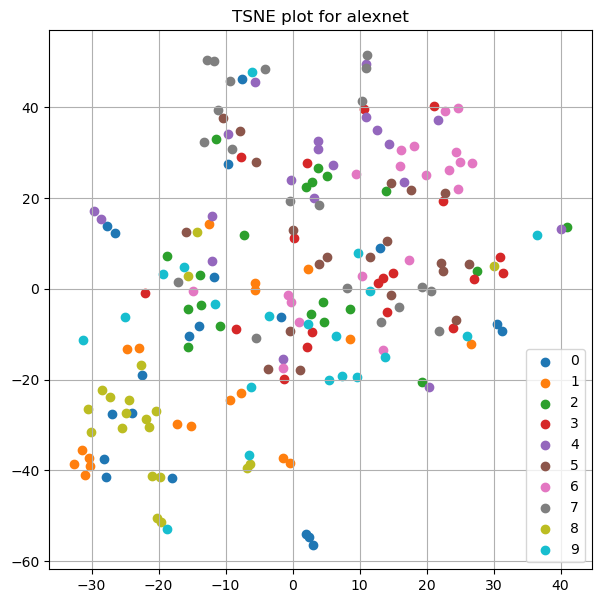

In [45]:
bottleneck_features_alex, targets_alex = [], []
with torch.no_grad():
    for images, labels in test_loader:
        # Get the bottleneck features
        bottleneck = alexnet.features(images)
        bottleneck = alexnet.avgpool(bottleneck)
        bottleneck = torch.flatten(bottleneck, 1)
        bottleneck_features_alex.append(bottleneck)
        targets_alex.append(labels)
bottleneck_features_alex = torch.cat(bottleneck_features_alex)
targets_alex = torch.cat(targets_alex)

print(type(bottleneck_features_alex))
embeddings = TSNE(2, init="random", perplexity=3).fit_transform(bottleneck_features_alex)
plt.figure(figsize=(7, 7))
for i in range(10):
    index = np.where(np.array(targets_alex) == i)[0]
    plt.scatter(embeddings[index, 0], embeddings[index, 1], label=str(i))

plt.title("TSNE plot for alexnet")
plt.legend()
plt.grid(True)
plt.show()

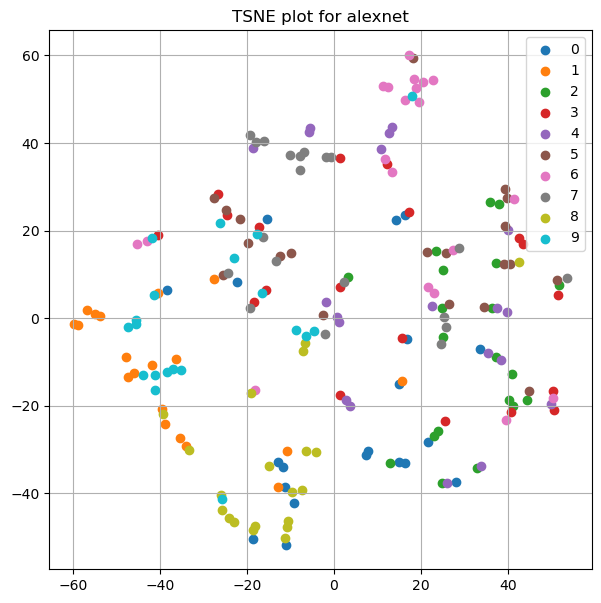

In [46]:
bottleneck_features_res, targets_res = [], []
with torch.no_grad():
    for images, labels in test_loader:
        bottleneck = resnet.conv1(images)
        bottleneck = resnet.bn1(bottleneck)
        bottleneck = resnet.relu(bottleneck)
        bottleneck = resnet.maxpool(bottleneck)
        bottleneck = resnet.layer1(bottleneck)
        bottleneck = resnet.layer2(bottleneck)
        bottleneck = resnet.layer3(bottleneck)
        bottleneck = resnet.layer4(bottleneck)
        bottleneck = resnet.avgpool(bottleneck)
        bottleneck = torch.flatten(bottleneck, 1)
        bottleneck_features_res.append(bottleneck)
        targets_res.append(labels)

bottleneck_features_res = torch.cat(bottleneck_features_res)
targets_res = torch.cat(targets_res)

embeddings = TSNE(2, init="random", perplexity=3).fit_transform(bottleneck_features_res)
plt.figure(figsize=(7, 7))
for i in range(10):
    index = np.where(np.array(targets_res) == i)[0]
    plt.scatter(embeddings[index, 0], embeddings[index, 1], label=str(i))

plt.title("TSNE plot for alexnet")
plt.legend()
plt.grid(True)
plt.show()

##### **1.E: Compare performance and comment on which model you would pick for this task**

In [73]:
print(f'Time taken by AlexNet: {time_alex}')
print(f'Time taken by ResNet: {time_res}')

print(f'Number of parameters in AlexNet: {sum(p.numel() for p in alexnet.parameters())}')
print(f'Number of parameters in ResNet: {sum(p.numel() for p in resnet.parameters())}')

Time taken by AlexNet: 1368.1977535999904
Time taken by ResNet: 2751.4425186000008
Number of parameters in AlexNet: 61100840
Number of parameters in ResNet: 11689512


Resnet takes more time even though it has very less parameters than AlexNet. Due to it's deeper architecture, it can catch more complexities. In my case, since I had taken a subset of data due to lack of time, it lead to overfitting, so alexnet was able to generalize better. But for a larger dataset, ResNet is better for handling complexities. If the data doesnot require capturing complex relationships, we can choose alexNet because of it's faster time.

## **Q2: TIME-SERIES MODELS**

##### **2.A: Replicate RNN tutorial**

In [48]:
from io import open
import glob
import os

def findFiles(path): return glob.glob(path)

print(findFiles('data/names/*.txt'))

import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

['data/names\\Arabic.txt', 'data/names\\Chinese.txt', 'data/names\\Czech.txt', 'data/names\\Dutch.txt', 'data/names\\English.txt', 'data/names\\French.txt', 'data/names\\German.txt', 'data/names\\Greek.txt', 'data/names\\Irish.txt', 'data/names\\Italian.txt', 'data/names\\Japanese.txt', 'data/names\\Korean.txt', 'data/names\\Polish.txt', 'data/names\\Portuguese.txt', 'data/names\\Russian.txt', 'data/names\\Scottish.txt', 'data/names\\Spanish.txt', 'data/names\\Vietnamese.txt']
Slusarski


In [49]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


In [50]:
import torch

# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))

print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


In [51]:
import torch.nn as nn
import torch.nn.functional as F

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        hidden = F.tanh(self.i2h(input) + self.h2h(hidden))
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

In [52]:
input = letterToTensor('A')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input, hidden)

In [53]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
print(output)

tensor([[-3.0207, -2.9692, -3.0040, -2.8041, -2.9154, -2.9164, -2.7389, -3.0566,
         -2.9185, -2.8933, -2.7355, -2.7595, -2.8724, -2.9524, -2.9904, -2.8889,
         -2.7804, -2.8923]], grad_fn=<LogSoftmaxBackward0>)


In [54]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

('Japanese', 10)


In [55]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = Russian / line = Valikhanov
category = Japanese / line = Joshuya
category = Russian / line = Levite
category = Vietnamese / line = To
category = Korean / line = Shin
category = Dutch / line = Paulissen
category = Portuguese / line = Madeira
category = Greek / line = Totolos
category = Korean / line = Son
category = Chinese / line = Hui


In [56]:
criterion = nn.NLLLoss()

In [57]:
learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden()

    rnn.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

In [58]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000



# Keep track of losses for plotting
current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    # Print ``iter`` number, loss, name and guess
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 13s) 2.3236 Poggio / Portuguese ✗ (Italian)
10000 10% (0m 30s) 2.3759 Rios / Greek ✗ (Portuguese)
15000 15% (0m 42s) 2.3267 Vipond / Irish ✗ (French)
20000 20% (0m 54s) 1.2131 Basara / Japanese ✗ (Arabic)
25000 25% (1m 6s) 3.8080 Botros / Portuguese ✗ (Arabic)
30000 30% (1m 18s) 1.0617 Cardozo / Spanish ✗ (Portuguese)
35000 35% (1m 30s) 0.9363 Ackary / English ✓
40000 40% (1m 43s) 2.9450 Graham / Arabic ✗ (Scottish)
45000 45% (1m 54s) 1.6786 Kolijn / English ✗ (Dutch)
50000 50% (2m 6s) 0.8589 Flynn / Irish ✓
55000 55% (2m 17s) 0.2045 Shao / Chinese ✓
60000 60% (2m 29s) 0.3682 Campos / Portuguese ✓
65000 65% (2m 42s) 0.7249 Evangelista / Italian ✓
70000 70% (2m 54s) 0.0488 Pispinis / Greek ✓
75000 75% (3m 5s) 1.9758 Heidl / German ✗ (Czech)
80000 80% (3m 17s) 0.2962 Alescio / Italian ✓
85000 85% (3m 29s) 0.0181 Banh / Vietnamese ✓
90000 90% (3m 41s) 0.3050 Hase / German ✓
95000 95% (3m 53s) 0.0194 Watson / Scottish ✓
100000 100% (4m 5s) 0.0803 Descoteaux / French ✓


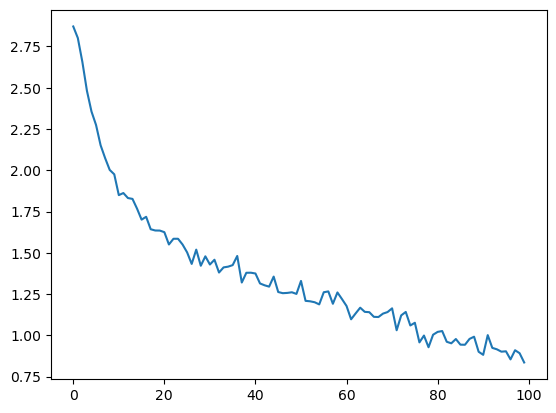

In [59]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

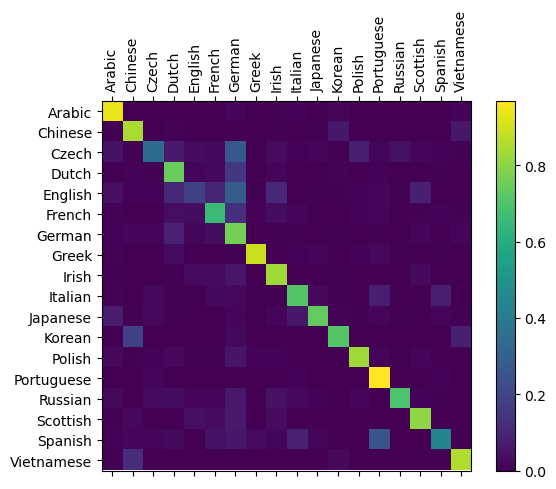

In [60]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

# Just return an output given a line
def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Set up plot
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

##### Utility functions modified from the above codes, to help for both GRU AND LSTM

In [61]:
def loop(model, category_tensor, line_tensor):
    hidden = model.initHidden()
    model.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = model(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    for p in model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

In [62]:
def trainModel(model, n_iters=100000, print_every=5000, plot_every=1000):
    current_loss = 0
    all_losses = []
    start = time.time()

    for iter in range(1, n_iters + 1):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output, loss = loop(model, category_tensor, line_tensor)
        current_loss += loss

        if iter % print_every == 0:
            guess, guess_i = categoryFromOutput(output)
            correct = '✓' if guess == category else '✗ (%s)' % category
            print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

        if iter % plot_every == 0:
            all_losses.append(current_loss / plot_every)
            current_loss = 0

    return current_loss, all_losses

In [63]:
def confusion_matrix(model, n_confusion=10000):
    confusion = torch.zeros(n_categories, n_categories)

    for i in range(n_confusion):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output = evaluate(line_tensor)
        guess, guess_i = categoryFromOutput(output)
        category_i = all_categories.index(category)
        confusion[category_i][guess_i] += 1

    for i in range(n_categories):
        confusion[i] = confusion[i] / confusion[i].sum()

    return confusion

##### **Using GRU and reporting performance**

In [64]:
# Using same function structure as RNN results replicated to be able to use same functions
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRU, self).__init__()

        self.hidden_size = hidden_size

        self.candidate = nn.Linear(input_size + hidden_size, hidden_size)
        self.update_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.reset_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)

        update = torch.sigmoid(self.update_gate(combined))
        reset = torch.sigmoid(self.reset_gate(combined))

        combined = torch.cat((input, reset * hidden), 1)
        candidate = torch.tanh(self.candidate(combined))

        hidden = (1 - update) * hidden + update * candidate

        output = self.h2o(hidden)
        output = self.softmax(output)

        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
gru = GRU(n_letters, n_hidden, n_categories)

In [65]:
current_loss_gru, all_losses_gru = trainModel(gru)

5000 5% (0m 23s) 2.7827 Mochtarev / French ✗ (Russian)
10000 10% (0m 47s) 2.8156 Cuocco / Portuguese ✗ (Italian)
15000 15% (1m 11s) 2.6676 Christy / Greek ✗ (English)
20000 20% (1m 35s) 2.9730 Koziol / Italian ✗ (Polish)
25000 25% (2m 0s) 1.0601 Ying / Chinese ✓
30000 30% (2m 24s) 1.1446 an / Vietnamese ✓
35000 35% (2m 49s) 1.0174 Ferro / Portuguese ✓
40000 40% (3m 14s) 1.0762 Cervenka / Czech ✓
45000 45% (3m 39s) 0.9028 Thao / Vietnamese ✓
50000 50% (4m 4s) 1.1208 Kada / Japanese ✓
55000 55% (4m 29s) 0.2804 Sardelis / Greek ✓
60000 60% (4m 55s) 1.0232 Blazek / Polish ✗ (Czech)
65000 65% (5m 20s) 1.2132 Tansho / Vietnamese ✗ (Japanese)
70000 70% (5m 45s) 1.1816 Sommer / German ✓
75000 75% (6m 10s) 0.6029 Aritza / Spanish ✓
80000 80% (6m 47s) 0.1161 Tassioglou / Greek ✓
85000 85% (7m 53s) 0.2839 Rodriguez / Spanish ✓
90000 90% (8m 32s) 1.9040 Kappel / Czech ✗ (German)
95000 95% (8m 58s) 0.0371 Hosokaya / Japanese ✓
100000 100% (9m 24s) 0.1311 Yamana / Japanese ✓


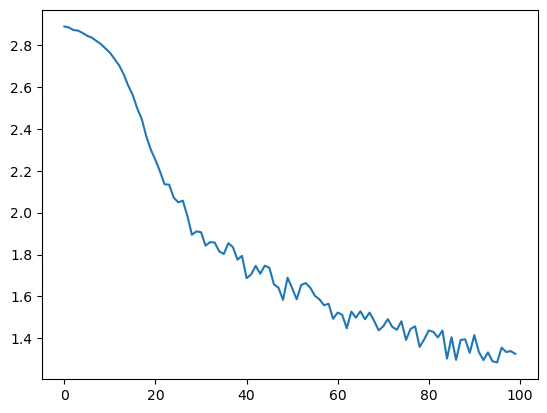

In [66]:
plt.figure()
plt.plot(all_losses_gru)

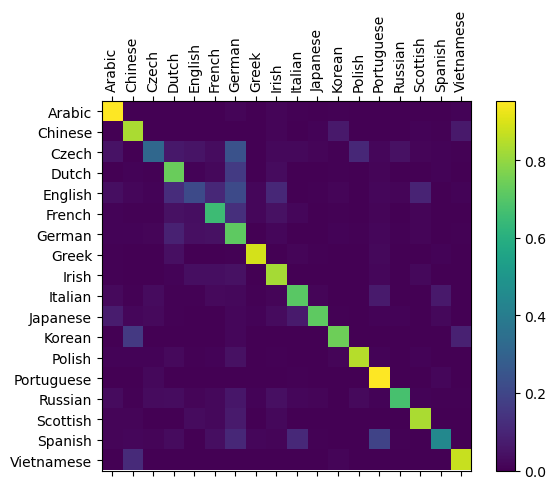

In [67]:
confusion_gru = confusion_matrix(GRU)
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion_gru.numpy())
fig.colorbar(cax)
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
plt.show()

##### **Using LSTM and reporting performance**

In [68]:
# Using same function structure as RNN results replicated to be able to use same functions
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()

        self.hidden_size = hidden_size

        self.candidate = nn.Linear(input_size + hidden_size, hidden_size)
        self.input_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.forget_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.output_gate = nn.Linear(input_size + hidden_size, hidden_size)

        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        cell_state, hidden = hidden

        combined = torch.cat((input, hidden), 1)
        input_gate = torch.sigmoid(self.input_gate(combined))
        forget_gate = torch.sigmoid(self.forget_gate(combined))
        output_gate = torch.sigmoid(self.output_gate(combined))
        candidate = torch.tanh(self.candidate(combined))

        cell_state = forget_gate * cell_state + input_gate * candidate
        hidden = output_gate * torch.tanh(cell_state)

        output = self.h2o(hidden)
        output = self.softmax(output)

        return output, (cell_state, hidden)

    def initHidden(self):
        return (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size))

n_hidden = 128
lstm = LSTM(n_letters, n_hidden, n_categories)

In [69]:
current_loss_lstm, all_losses_lstm = trainModel(lstm)

5000 5% (0m 34s) 2.8104 Blaise / French ✓
10000 10% (1m 5s) 2.8671 Villanueva / Arabic ✗ (Spanish)
15000 15% (1m 35s) 2.8622 Jarzembowski / Japanese ✗ (Czech)
20000 20% (2m 1s) 2.8375 Wan / Czech ✗ (Chinese)
25000 25% (2m 27s) 2.8040 Phung / Irish ✗ (Vietnamese)
30000 30% (2m 53s) 2.2805 Christodoulou / Greek ✓
35000 35% (3m 19s) 2.3783 Soares / Greek ✗ (Portuguese)
40000 40% (3m 46s) 1.4836 Chong / Vietnamese ✗ (Chinese)
45000 45% (4m 12s) 2.6125 Gosselin / Russian ✗ (French)
50000 50% (4m 38s) 2.5312 Docherty / German ✗ (Scottish)
55000 55% (5m 4s) 3.0447 Nghiem / Arabic ✗ (Vietnamese)
60000 60% (5m 30s) 1.9004 Tully / Irish ✗ (English)
65000 65% (5m 56s) 0.9259 Franco / Portuguese ✓
70000 70% (6m 21s) 1.2087 Guo / Korean ✗ (Chinese)
75000 75% (6m 47s) 3.7098 Marqueringh / Russian ✗ (Dutch)
80000 80% (7m 13s) 1.6504 Forman / Scottish ✗ (English)
85000 85% (7m 39s) 0.7241 Samios / Greek ✓
90000 90% (8m 5s) 3.1951 Jamussa / Japanese ✗ (Greek)
95000 95% (8m 31s) 1.4251 Bautista / Italia

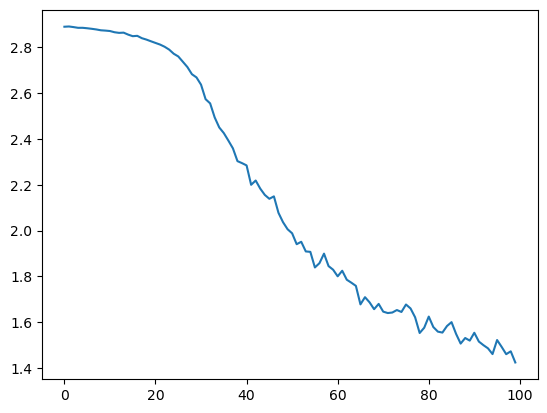

In [70]:
plt.figure()
plt.plot(all_losses_lstm)

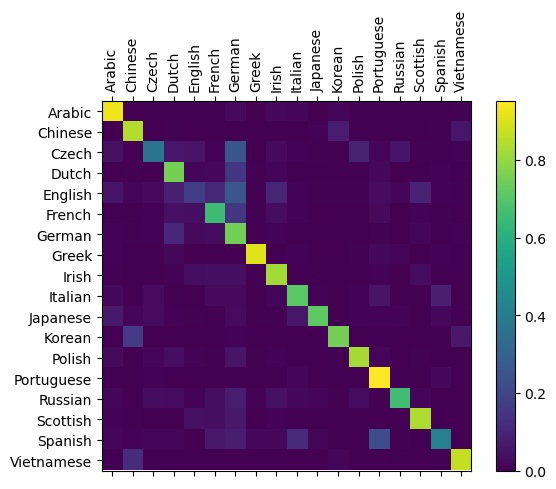

In [71]:
confusion_lstm = confusion_matrix(lstm)
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion_lstm.numpy())
fig.colorbar(cax)
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
plt.show()